In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IOT-temp.csv to IOT-temp.csv


In [ ]:
import pandas as pd

df = pd.read_csv("IOT-temp.csv")
df.head()

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB


,0
id,0
room_id/id,0
noted_date,0
temp,0
out/in,0


In [ ]:
df = df[['noted_date', 'temp']]

In [ ]:
df.rename(columns={
    'noted_date': 'Time',
    'temp': 'Temperature'
}, inplace=True)

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%d-%m-%Y %H:%M')

In [ ]:
df = df.sort_values(by='Time')
df = df.reset_index(drop=True)

In [ ]:
df = df.head(4000)
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Time         4000 non-null   datetime64[ns]
 1   Temperature  4000 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 62.6 KB


,0
Time,0
Temperature,0


In [ ]:
from scipy import stats
import numpy as np

df['Z_score'] = np.abs(stats.zscore(df['Temperature']))

In [ ]:
df['Outlier'] = df['Z_score'] > 3

df['Outlier'].value_counts()

,count
Outlier,
False,3998
True,2


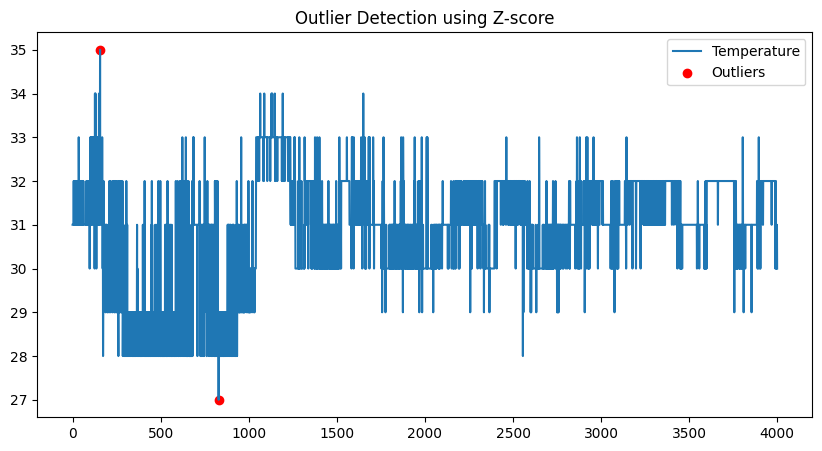

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Temperature'], label='Temperature')
plt.scatter(df.index[df['Outlier']],
            df['Temperature'][df['Outlier']],
            color='red', label='Outliers')

plt.legend()
plt.title("Outlier Detection using Z-score")
plt.show()

In [ ]:
df['Smoothed_Temp'] = df['Temperature'].copy()
outlier_indices = df.index[df['Outlier']]

for i in outlier_indices:
    start_idx = max(i - 10, 0)
    df.loc[i, 'Smoothed_Temp'] = df['Temperature'][start_idx:i].mean()

/tmp/ipykernel_10099/1313220696.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '31.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Smoothed_Temp'] = df['Temperature'][start_idx:i].mean()


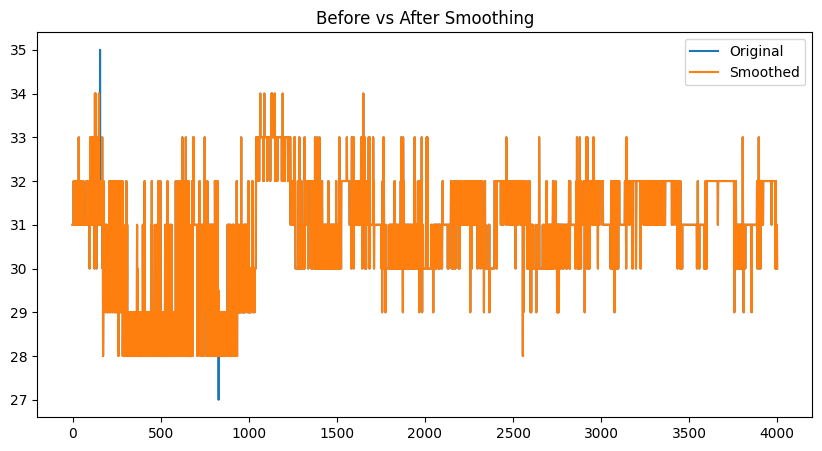

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Temperature'], label='Original')
plt.plot(df['Smoothed_Temp'], label='Smoothed')

plt.legend()
plt.title("Before vs After Smoothing")
plt.show()

In [ ]:
df.to_csv("cleaned_sensor_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_sensor_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>